# FinSight Innovations: Data-Driven NSE(Nairobi Securities Exchange) Analysis

## Overview
*BLUF (Bottom Line Up Front)*
- **Performance**: We successfully developed a robust machine learning pipeline that predicts short-term stock price movements (Up/Down) with a test accuracy of **75%** and a **ROC-AUC of 0.795**.
- **Methodology**: The model utilizes an **XGBoost Classifier** with strict chronological validation (`TimeSeriesSplit`), effectively eliminating look-ahead bias to reliably predict unseen market data.
- **Key Insights**: Analysis confirms that **recent price changes** and **Daily Returns** are the dominant predictive signals, significantly outperforming lagged variables and volume metrics.
- **Business Impact**: Although in its early stages of optimization, the model functions as an institutional-level prediction tool. It generates actionable, probability-weighted forecasts for the tracked stocks, providing a solid foundation for data-driven portfolio managements.

*Summary*
- The model has succesfuly gone beyond the testing phase and we speculate that although in it's early stages of optimization and fine-tunning it can function as an institutional-level prediction tool capable of generating actionable, probability-weighted forecasts for any of the 60 tracked stocks providing a foundaton for data-driven portfolio managment.

## Business Understanding

### 1. Business Context & Problem Definition
- This project operates within the domain of quantitative finance and algorithimic trading. The project consists of a diverse portfolio of 60 stocks spanning 14 distinct sectors over a 6 month period, ensuring major reach and relevance across institutions. In the highly volatile and noisy market environment institutional investors, portfolio managers and traders require objective data-driven insights to mitigate risks and identify trading opportunities thus reducing their reliance on intuiton and basic market observations.
- Therefore, the core **business problem** is the inherent unpredictability of short-term stock price direction. The project needs to determine whether historical technical indicators(SMA & EMA), price changes, volume metrics and volatility measures contain statistically significant information that can reliably predict the direction of a stock's price movement for the next trading period. This basically means the business problems would be categorised as : 
   - **(1). Predictive reliability** -
      * Determines how accurately the model will classify the next day's market movements without falling victim to common model pitfalls such as look-ahead bias(data leakage)
   - **(2). Specific Actionability** -
      * Reliably evaluate and predict each institution's directional stock forecast accompanied by a reliable probability confidence score 
### 2. Modeling Goals & Success Criteria
- The following are the **goals** of the model:
  - Target Formulation 
     * Convert continous stock price data into a reliable binary calssification target i.e.(1=price up, 0=price down/not up)  
  - Feature Engineering and Selection 
     * Evaluate a matrix of 28 technical indicators to identify the most influential market indicators
  - Institution-Level Inference Engine
     * Develop a Predictive function that isolates the latest available price records and uses the trained model to generate a probability-weighted directional forecast.
  - Extensive Temporal Validation 
     * Implement a strict chronological train/test splitand use 5-fold TimeSeries C.V. This ensures the complete elimination of look-ahead bias

- The following are the **success criteria** for model :
  - Technical performance metrics
    * **Metric 1- ROC-AUC (Receiver Operating Characteristic - Area Under Curve).** Achieve a score of ~ 0.75
    * **Metric 2- Test Accuracy Score** Achieve a test accuracy score of ~75% 
  - No data Leakage - The model can only be a success if it strictly adheres to chronological splitting and time-series cross validation.
  - Business Actionability & Interpretability
    * Feature importance must yield logical and interpretable results allowing for stakeholders to understand the why behind the prediction giving it more credibility
    * The model mut correctly generate confidence score predictions for the stock shifts of each tracked institution  

## Data Understanding
 - Conduct comprehensive exploratory data analysis:


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the data
stock_data = pd.read_csv('NSE_data_all_stocks_2026_upto_jun.csv')
sector_data = pd.read_csv('NSE_data_stock_market_sectors_2026.csv')

In [ ]:
# Check data quality and structure
print("Stock Data Shape:", stock_data.shape)
print("\nFirst 5 rows of Stock Data:")
stock_data.head(5)

Stock Data Shape: (9280, 13)

First 5 rows of Stock Data:


,Date,Code,Name,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjusted Price
0,2-Jan-26,EGAD,Eaagads Ltd,11.0,35.25,18.5,20.50,20.30,20.5,-0.2,-0.98%,1136,-
1,2-Jan-26,KUKZ,Kakuzi Plc,365.0,440.00,390.0,405.00,402.00,402,-,-,84,-
2,2-Jan-26,KAPC,Kapchorua Tea Kenya Plc,198.0,424.25,230.0,235.75,233.00,231.5,1.5,0.65%,699,-
3,2-Jan-26,LIMT,Limuru Tea Plc,295.0,555.00,460.0,460.00,460.00,460,-,-,-,-
4,2-Jan-26,SASN,Sasini Plc,13.3,33.90,17.9,18.90,18.15,17.85,0.3,1.68%,4127,-


In [ ]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9280 entries, 0 to 9279
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            9280 non-null   object 
 1   Code            9280 non-null   object 
 2   Name            9280 non-null   object 
 3   12m Low         9280 non-null   float64
 4   12m High        9280 non-null   float64
 5   Day Low         9280 non-null   float64
 6   Day High        9280 non-null   float64
 7   Day Price       9280 non-null   float64
 8   Previous        9280 non-null   object 
 9   Change          9280 non-null   object 
 10  Change%         9280 non-null   object 
 11  Volume          9280 non-null   object 
 12  Adjusted Price  9280 non-null   object 
dtypes: float64(5), object(8)
memory usage: 942.6+ KB


In [ ]:
# Check for missing values in stock_data
stock_data.isnull().sum()

Date              0
Code              0
Name              0
12m Low           0
12m High          0
Day Low           0
Day High          0
Day Price         0
Previous          0
Change            0
Change%           0
Volume            0
Adjusted Price    0
dtype: int64

In [ ]:
print("Sector Data Shape:", sector_data.shape)
print("\nFirst 5 rows of Sector Data:")
sector_data.head(5)

Sector Data Shape: (77, 3)

First 5 rows of Sector Data:


,Sector,Stock_code,Stock_name
0,Agricultural,EGAD,Eaagads Ltd
1,Agricultural,KUKZ,Kakuzi Plc
2,Agricultural,KAPC,Kapchorua Tea Kenya Plc
3,Agricultural,LIMT,Limuru Tea Plc
4,Agricultural,SASN,Sasini Plc


In [ ]:
sector_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Sector      77 non-null     object
 1   Stock_code  77 non-null     object
 2   Stock_name  77 non-null     object
dtypes: object(3)
memory usage: 1.9+ KB


In [ ]:
# Number of Unique Sectors
sector_data['Sector'].nunique()

14

In [ ]:
# Check for missing values in sector_data
sector_data.isnull().sum()

Sector        0
Stock_code    0
Stock_name    0
dtype: int64

In [ ]:
# Join the two datasets on the Code column
df = pd.merge(stock_data, sector_data, left_on='Code', right_on='Stock_code', how='left')

# Print the joined Dataset
print("Joint Data Shape:", df.shape)
print("\nFirst 5 rows of Joint Data:")
df.head(5)

Joint Data Shape: (9280, 16)

First 5 rows of Joint Data:


,Date,Code,Name,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Adjusted Price,Sector,Stock_code,Stock_name
0,2-Jan-26,EGAD,Eaagads Ltd,11.0,35.25,18.5,20.50,20.30,20.5,-0.2,-0.98%,1136,-,Agricultural,EGAD,Eaagads Ltd
1,2-Jan-26,KUKZ,Kakuzi Plc,365.0,440.00,390.0,405.00,402.00,402,-,-,84,-,Agricultural,KUKZ,Kakuzi Plc
2,2-Jan-26,KAPC,Kapchorua Tea Kenya Plc,198.0,424.25,230.0,235.75,233.00,231.5,1.5,0.65%,699,-,Agricultural,KAPC,Kapchorua Tea Kenya Plc
3,2-Jan-26,LIMT,Limuru Tea Plc,295.0,555.00,460.0,460.00,460.00,460,-,-,-,-,Agricultural,LIMT,Limuru Tea Plc
4,2-Jan-26,SASN,Sasini Plc,13.3,33.90,17.9,18.90,18.15,17.85,0.3,1.68%,4127,-,Agricultural,SASN,Sasini Plc


- Clean Joint Dataset 

In [ ]:
# Convert Volume and Adjusted Price to numeric ('-' becomes NaN)
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')
df['Adjusted Price'] = pd.to_numeric(df['Adjusted Price'], errors='coerce')
df['Previous'] = pd.to_numeric(df['Previous'], errors='coerce')

# Clean Change% (remove '%' and handle '-' or '#VALUE!' as 0)
df['Change%'] = df['Change%'].astype(str).str.replace('%', '', regex=False).replace(['-', '#VALUE!'], '0').astype(float)
# Clean Change (handle '-' or '#VALUE!' as 0)
df['Change'] = df['Change'].astype(str).replace(['-', '#VALUE!'], '0').astype(float)

# Convert Date to datetime (format matches '2-Jan-26')
df['Date'] = pd.to_datetime(df['Date'], format='%d-%b-%y')

# Drop rows with missing values in critical columns
df = df.dropna(subset=['Day Price', 'Previous', 'Volume'])

# Drop the empty Adjusted Price column 
df = df.drop(columns=['Adjusted Price'])
df.head(10)

,Date,Code,Name,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Sector,Stock_code,Stock_name
0,2026-01-02,EGAD,Eaagads Ltd,11.00,35.25,18.5,20.50,20.30,20.50,-0.20,-0.98,1136.0,Agricultural,EGAD,Eaagads Ltd
1,2026-01-02,KUKZ,Kakuzi Plc,365.00,440.00,390.0,405.00,402.00,402.00,0.00,0.00,84.0,Agricultural,KUKZ,Kakuzi Plc
2,2026-01-02,KAPC,Kapchorua Tea Kenya Plc,198.00,424.25,230.0,235.75,233.00,231.50,1.50,0.65,699.0,Agricultural,KAPC,Kapchorua Tea Kenya Plc
4,2026-01-02,SASN,Sasini Plc,13.30,33.90,17.9,18.90,18.15,17.85,0.30,1.68,4127.0,Agricultural,SASN,Sasini Plc
5,2026-01-02,WTK,Williamson Tea Kenya Plc,136.00,350.00,149.0,155.00,150.00,149.50,0.50,0.33,24702.0,Agricultural,WTK,Williamson Tea Kenya Plc
6,2026-01-02,CGEN,Car and General (K) Ltd,19.80,74.25,51.0,56.00,51.00,51.00,0.00,0.00,25.0,Automobiles and Accessories,CGEN,Car and General (K) Ltd
7,2026-01-02,ABSA,ABSA Bank Kenya Plc,15.00,33.00,24.3,25.45,24.85,24.70,0.15,0.61,140294.0,Banking,ABSA,ABSA Bank Kenya Plc
8,2026-01-02,BKG,BK Group Plc,28.75,52.00,38.5,43.00,40.55,42.50,-1.95,-4.59,2113.0,Banking,BKG,BK Group Plc
9,2026-01-02,COOP,Co-operative Bank of Kenya Ltd,13.80,31.50,23.4,24.00,23.90,23.95,-0.05,-0.21,125042.0,Banking,COOP,Co-operative Bank of Kenya Ltd
10,2026-01-02,DTK,Diamond Trust Bank Kenya Ltd,66.00,170.00,113.5,115.00,114.75,114.50,0.25,0.22,4393.0,Banking,DTK,Diamond Trust Bank Kenya Ltd


In [ ]:
# Check cleaned shape
df.shape

(6914, 15)

In [ ]:
# Check data types and non-null counts after cleaning 
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6914 entries, 0 to 9271
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        6914 non-null   datetime64[ns]
 1   Code        6914 non-null   object        
 2   Name        6914 non-null   object        
 3   12m Low     6914 non-null   float64       
 4   12m High    6914 non-null   float64       
 5   Day Low     6914 non-null   float64       
 6   Day High    6914 non-null   float64       
 7   Day Price   6914 non-null   float64       
 8   Previous    6914 non-null   float64       
 9   Change      6914 non-null   float64       
 10  Change%     6914 non-null   float64       
 11  Volume      6914 non-null   float64       
 12  Sector      6909 non-null   object        
 13  Stock_code  6909 non-null   object        
 14  Stock_name  6909 non-null   object        
dtypes: datetime64[ns](1), float64(9), object(5)
memory usage: 864.2+ KB


In [ ]:
# Order the DataFrame by Date and Code for better analysis
df = df.sort_values(by=['Code', 'Date']).reset_index(drop=True)
df.head(10)

,Date,Code,Name,12m Low,12m High,Day Low,Day High,Day Price,Previous,Change,Change%,Volume,Sector,Stock_code,Stock_name
0,2026-01-02,ABSA,ABSA Bank Kenya Plc,15.0,33.0,24.30,25.45,24.85,24.70,0.15,0.61,140294.0,Banking,ABSA,ABSA Bank Kenya Plc
1,2026-01-05,ABSA,ABSA Bank Kenya Plc,15.0,33.0,24.00,26.00,25.45,24.85,0.60,2.41,253463.0,Banking,ABSA,ABSA Bank Kenya Plc
2,2026-01-06,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.00,26.50,26.05,25.45,0.60,2.36,544062.0,Banking,ABSA,ABSA Bank Kenya Plc
3,2026-01-07,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.00,26.00,25.65,26.05,-0.40,-1.54,345242.0,Banking,ABSA,ABSA Bank Kenya Plc
4,2026-01-08,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.10,25.75,25.50,25.65,-0.15,-0.58,323372.0,Banking,ABSA,ABSA Bank Kenya Plc
5,2026-01-09,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.35,26.00,25.55,25.50,0.05,0.20,1961778.0,Banking,ABSA,ABSA Bank Kenya Plc
6,2026-01-12,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.30,26.00,25.70,25.55,0.15,0.59,2483805.0,Banking,ABSA,ABSA Bank Kenya Plc
7,2026-01-13,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.60,26.00,25.70,25.70,0.00,0.00,1542924.0,Banking,ABSA,ABSA Bank Kenya Plc
8,2026-01-14,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.60,26.00,25.70,25.70,0.00,0.00,3073075.0,Banking,ABSA,ABSA Bank Kenya Plc
9,2026-01-15,ABSA,ABSA Bank Kenya Plc,15.0,33.0,25.70,26.00,25.80,25.70,0.10,0.39,300910.0,Banking,ABSA,ABSA Bank Kenya Plc


In [ ]:
# Engineering features
df = df.copy()

# 1. Lag features (past prices)
for lag in [1, 2, 3, 5, 10]:
    df[f'Lag_{lag}'] = df.groupby('Code')['Day Price'].shift(lag)

# 2. Rolling averages and volatility
for window in [5, 10, 20]:
    df[f'MA_{window}'] = df.groupby('Code')['Day Price'].transform(
        lambda x: x.rolling(window, min_periods=1).mean())
    df[f'Vol_{window}'] = df.groupby('Code')['Day Price'].transform(
        lambda x: x.rolling(window, min_periods=2).std())

# 3. Price ratios & Returns
df['Price_to_High'] = df['Day Price'] / df['12m High']
df['Price_to_Low'] = df['Day Price'] / df['12m Low']
df['Daily_Return'] = df.groupby('Code')['Day Price'].pct_change()

# 4. Date features
df['Day_of_Week'] = df['Date'].dt.dayofweek  
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# 5. Volume features
df['Volume_MA_5'] = df.groupby('Code')['Volume'].transform(
    lambda x: x.rolling(5, min_periods=1).mean())
df['Volume_Ratio'] = df['Volume'] / df['Volume_MA_5']

# Advanced Technical Indicators
# EMAs
for window in [5, 10, 20]:
    df[f'EMA_{window}'] = df.groupby('Code')['Day Price'].transform(
        lambda x: x.ewm(span=window, adjust=False).mean())

# RSI (14-day)
def calc_rsi(group, window=14):
    delta = group['Day Price'].diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=window, min_periods=1).mean()
    avg_loss = loss.rolling(window=window, min_periods=1).mean()
    rs = avg_gain / avg_loss
    group['RSI_14'] = 100 - (100 / (1 + rs))
    return group
df = df.groupby('Code', group_keys=False).apply(calc_rsi)

# MACD
ema_12 = df.groupby('Code')['Day Price'].transform(lambda x: x.ewm(span=12, adjust=False).mean())
ema_26 = df.groupby('Code')['Day Price'].transform(lambda x: x.ewm(span=26, adjust=False).mean())
df['MACD'] = ema_12 - ema_26
df['MACD_Signal'] = df.groupby('Code')['MACD'].transform(lambda x: x.ewm(span=9, adjust=False).mean())
df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']

# Momentum (10-day)
df['Momentum_10'] = df.groupby('Code')['Day Price'].pct_change(10)

# --- 7. Target Formulation (FIXED: Binary Classification) ---
next_price = df.groupby('Code')['Day Price'].shift(-1)
df['Target'] = (next_price > df['Day Price']).astype(int) # 1 = Up, 0 = Down/Flat

# Accurate count of engineered feature columns
engineered_cols = [col for col in df.columns if col not in ['Date', 'Code', 'Name', '12m Low', '12m High', 
                 'Day Low', 'Day High', 'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 
                 'Sector', 'Stock_code', 'Stock_name']]
print(f"Features engineered: {len(engineered_cols)} new technical indicators")

Features engineered: 28 new technical indicators


In [ ]:
# Performing quality checks & Handling Missing Values
missing_before = df.isnull().sum()

# Define columns that will naturally have NaNs due to lags/rolling/target shifts
nan_prone_cols = [c for c in df.columns if any(c.startswith(p) for p in 
                  ['Lag_', 'Vol_', 'MA_', 'EMA_', 'RSI_', 'MACD', 'Momentum', 'Daily_Return', 'Volume_Ratio', 'Target'])]

# Drop rows where engineered features or targets are NaN
initial_rows = len(df)
df = df.dropna(subset=nan_prone_cols).reset_index(drop=True)
dropped_rows = initial_rows - len(df)

print(f"Missing Value Resolution:")
print(f"\nDropped {dropped_rows} rows due to NaNs from lags/rolling/target shifts.")
print(f"Final clean dataset shape: {df.shape}")

# Verify no missing values remain in critical modeling columns
remaining_missing = df[nan_prone_cols].isnull().sum().sum()
if remaining_missing == 0:
    print("No missing values in engineered features or target.")
else:
    print(f"{remaining_missing} missing values still exist in the dataset.")

Missing Value Resolution:

Dropped 0 rows due to NaNs from lags/rolling/target shifts.
Final clean dataset shape: (6307, 43)
No missing values in engineered features or target.


In [ ]:
# Save cleaned and feature-engineered dataset to CSV
df.to_csv('NSE_cleaned_stock_data_with_features.csv', index=False)

## Feature Definition 

The features we have selected are desgned to accurately capture distinct market behaviour and predict short term stock movement. Therefore, many features covering a wide field have been chosen in order to ensure the accuracy can be pushed to as high a value as possible.
The following  are the subsequent explanatons and groupings for said features:

### 1. Trend & Momentum Indicators
These features help the model identify the direction and strength of recent price movements.
*   **Lag Features (`Lag_1` to `Lag_10`) & `Daily_Return`**
    *   **What they represent:** The absolute price of the stock, 1 to 10 days ago, and the percentage change from the previous day.
    *   **Why chosen:** They accurately capture **short-term momentum**. In algorithmic trading, recent price changes are often the strongest predictors of immediate next-day movements i.e.trend continuation or short-term reversal.
*   **Simple Moving Averages (`MA_5`, `MA_10`, `MA_20`)**
    *   **What they represent:** The average closing price over the last 5, 10 and 20 days.
    *   **Why chosen:** They act as **trend filters**. They smooth out daily noise to reveal the underlying direction. Comparing the current price to the `MA_5` vs `MA_20` helps the model understand if a stock is in a short-term or medium-term uptrend/downtrend.
*   **Exponential Moving Averages (`EMA_5`, `EMA_10`, `EMA_20`)**
    *   **What they represent:** Moving averages that apply more weight to recent data points.
    *   **Why chosen:** EMAs react to recent price changes faster than SMAs. In short-term prediction i.e.1-day ahead, EMAs are often more responsive to sudden market shifts than SMAs hence there inclusion.
*   **Momentum (`Momentum_10`)**
    *   **What it represents:** The percentage price change over the last 10 days.
    *   **Why chosen:** Captures the **velocity/intensity** of the price trend over a slightly longer horizon than daily returns, helping identify sustained breakouts.

### 2. Oscillators & Mean-Reversion Indicators
These features help the model identify when a stock is overextended and due for a pullback or bounce up.
*   **Relative Strength Index (`RSI_14`)**
    *   **What it represents:** A bounded oscillator (0 to 100) measuring the speed and change of price movements. 
    *   **Why chosen:** It identifies **overbought (>70) or oversold (<30)** conditions. It provides the model with mean-reversion signals (e.g., if a stock is heavily oversold, the probability of a next-day "Up" bounce increases).
*   **MACD Components (`MACD`, `MACD_Signal`, `MACD_Hist`)**
    *   **What they represent:** The difference between the 12-day and 26-day EMAs (MACD), its 9-day EMA (Signal), and the distance between the two (Histogram).
    *   **Why chosen:** MACD is a classic **trend-following momentum indicator**. The histogram provides the model with early signals of momentum shifts (e.g., histogram turning from negative to positive often precedes an upward price movement).

### 3. Volatility & Risk Indicators
Volatility is crucial for understanding market risk and potential breakouts.
*   **Rolling Volatility (`Vol_5`, `Vol_10`, `Vol_20`)**
    *   **What they represent:** The rolling standard deviation of prices over 5, 10, and 20 days.
    *   **Why chosen:** Acts as a proxy for **market risk and uncertainty**. High volatility can indicate panic selling or explosive breakouts. The model can learn that high `Vol_5` might increase the probability of extreme next-day moves (in either direction).

### 4. Price Position & Support/Resistance
These features contextualize the current price relative to historical boundaries.
*   **Price Ratios (`Price_to_High`, `Price_to_Low`)**
    *   **What they represent:** The current price divided by the 52-week (12-month) high and low.
    *   **Why chosen:** They tell the model where the stock sits in its **annual range**. A `Price_to_High` near 1.0 indicates the stock is at peak resistance (potential breakout or rejection), while a `Price_to_Low` near 1.0 indicates it is at historical support.

### 5. Volume & Liquidity Indicators
Price movements without volume are often considered "fakeouts." Volume confirms trends.
*   **Volume Features (`Volume_MA_5`, `Volume_Ratio`)**
    *   **What they represent:** The 5-day average volume, and the ratio of today's volume to that 5-day average.
    *   **Why chosen:** To measure **relative trading activity and institutional interest**. A `Volume_Ratio` > 1.5 combined with a positive `Daily_Return` gives the model a high-confidence signal that the upward move is backed by strong market participation.

### 6. Calendar & Seasonality Features
Markets often exhibit behavioral patterns tied to the calendar.
*   **Date Features (`Day_of_Week`, `Month`, `Quarter`)**
    *   **What they represent:** Categorical time markers.
    *   **Why chosen:** To capture **institutional behavior and market microstructure anomalies**. For example, your EDA showed that Friday has the highest average trading volume. The model can learn if certain days (e.g., "Turnaround Tuesday" or Friday profit-taking) have a statistically significant bias toward Up or Down movements.

---

### Summary of Alignment with Business Goals
1.  **No Look-Ahead Bias:** All indicators are calculated using strictly historical, backward-looking data (`shift()`, `rolling()`), satisfying the strict chronological validation requirement.
2.  **Institutional Relevance:** By including Volume Ratios and 52-week High/Lows, the model accounts for liquidity and support/resistance levels, which are critical for institutional portfolio managers executing trades without causing massive slippage.
3.  **Interpretability:** Because these are standard, universally understood financial metrics, the resulting XGBoost Feature Importance charts will yield logical, defensible insights for stakeholders (e.g., "The model relies heavily on RSI and Daily Returns, which aligns with standard momentum trading strategies").

- **Exploratory Data Analysis(EDA)**

In [ ]:
clean = df.copy()

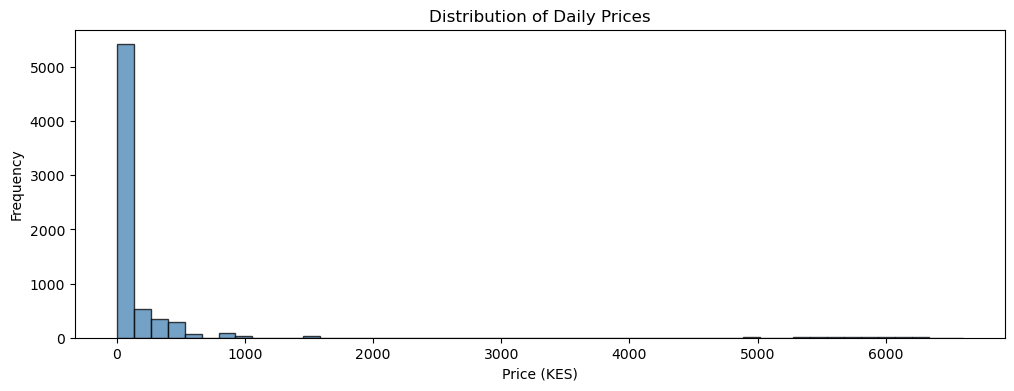

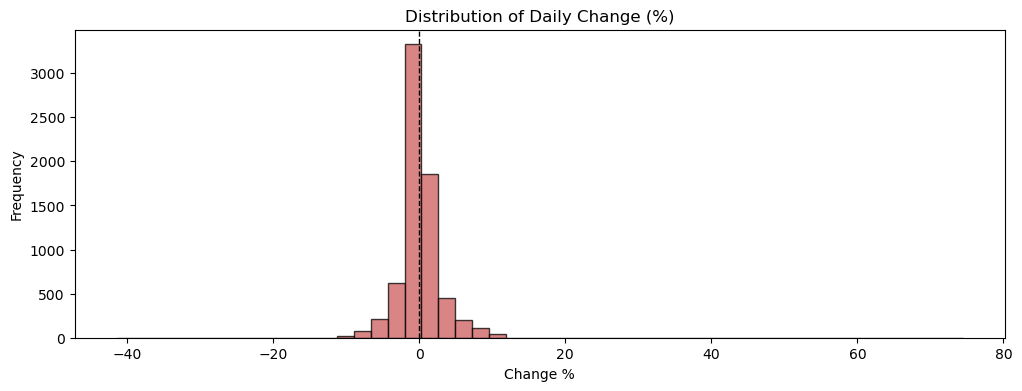

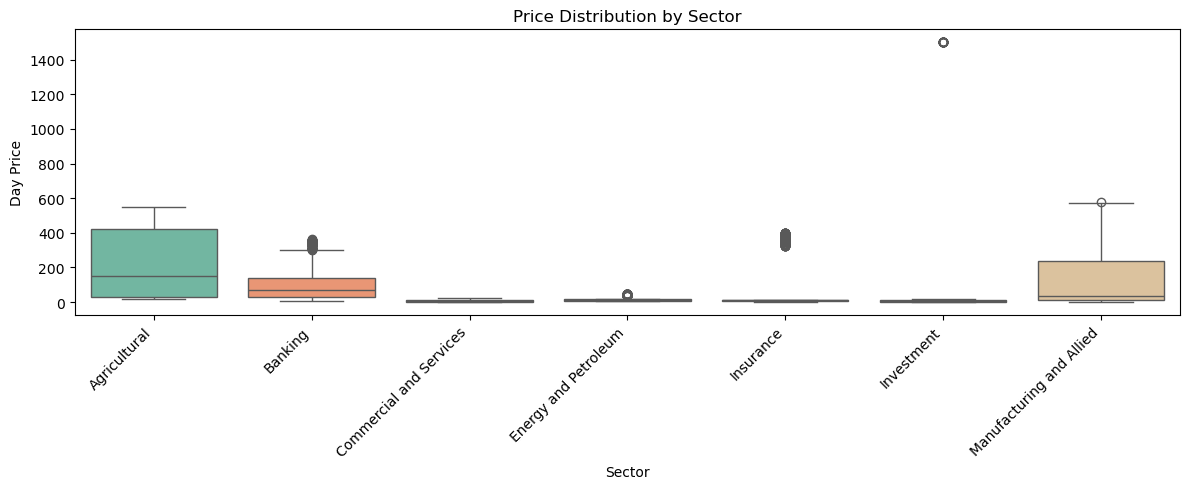

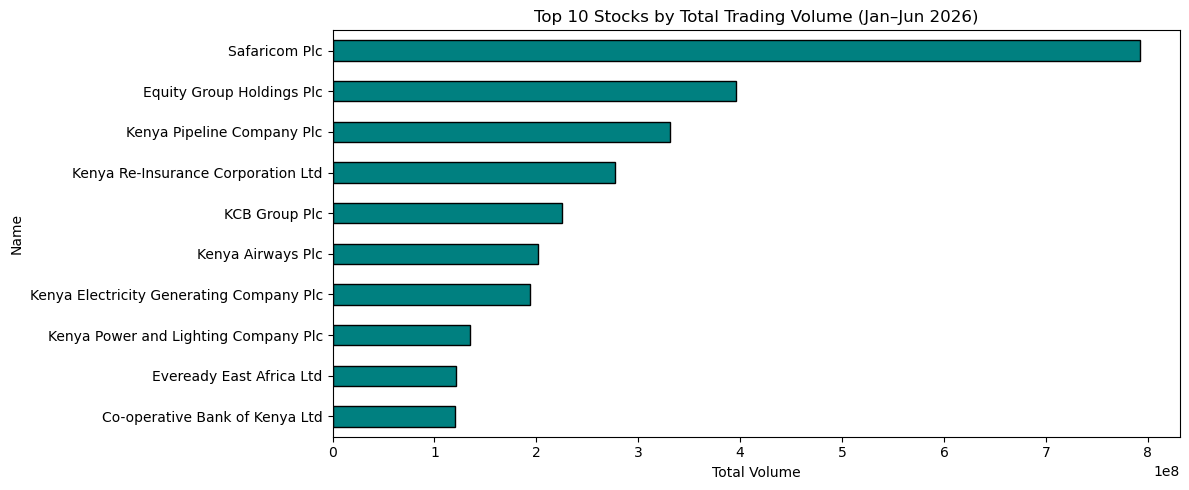

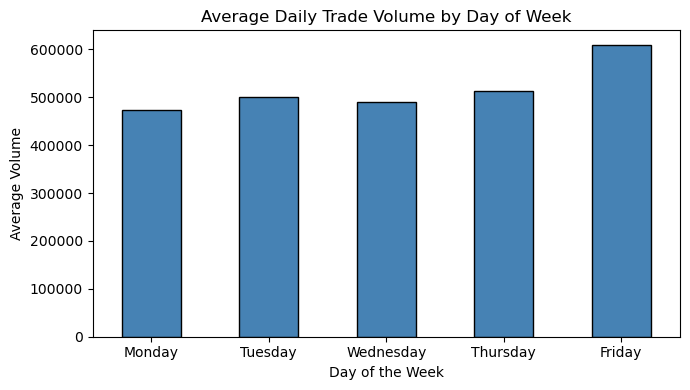

Average Daily Trade Volume by Day of Week:
Day_Name
Monday       473293.16
Tuesday      501343.65
Wednesday    490467.29
Thursday     512383.59
Friday       609448.07
Name: Volume, dtype: float64



In [ ]:
# 1. Price Distribution
plt.figure(figsize=(12, 4))
plt.hist(clean['Day Price'].dropna(), bins=50, alpha=0.75, color='steelblue', edgecolor='black')
plt.title('Distribution of Daily Prices')
plt.xlabel('Price (KES)')
plt.ylabel('Frequency')
plt.show()

# 2. Return Distribution (Crucial for understanding volatility and outliers)
plt.figure(figsize=(12, 4))
plt.hist(clean['Change%'].dropna(), bins=50, alpha=0.75, color='indianred', edgecolor='black')
plt.title('Distribution of Daily Change (%)')
plt.xlabel('Change %')
plt.ylabel('Frequency')
plt.axvline(0, color='black', linestyle='dashed', linewidth=1) # Add zero line for reference
plt.show()

# 3. Price Range by Sector
sector_counts = clean.groupby('Sector', observed=True)['Code'].nunique()
top_sectors = sector_counts[sector_counts >= 3].index.tolist()

plt.figure(figsize=(12, 5))
sns.boxplot(data=clean[clean['Sector'].isin(top_sectors)], x='Sector', y='Day Price', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Price Distribution by Sector')
plt.tight_layout()
plt.show()

# 4. Trading Activity (Top 10 by Volume)
top_volume = clean.groupby('Name', observed=True)['Volume'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_volume.sort_values().plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Stocks by Total Trading Volume (Jan–Jun 2026)')
plt.xlabel('Total Volume')
plt.tight_layout()
plt.show()

# 5. Day of the Week Volume Pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
clean['Day_Name'] = clean['Date'].dt.day_name()
volume_by_day = clean.groupby('Day_Name')['Volume'].mean().reindex(day_order)

plt.figure(figsize=(7, 4))
volume_by_day.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Average Daily Trade Volume by Day of Week')
plt.ylabel('Average Volume')
plt.xlabel('Day of the Week')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Average Daily Trade Volume by Day of Week:\n{volume_by_day.round(2)}\n")
